In [1]:
#packages
import requests
import pandas as pd
import json
from glob import glob
from pathlib import Path
import csv
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import plotly.express as px

import geopandas as gpd

# STEP A — PCA on outage variables (tract-level)

Procedure:

    • Standardize variables
    • Run PCA
    • Keep PC1–PC3 (likely ≥60–80% variance)
    • Extract tract-level PCA scores

Figures:

    • Scree plot
    • Loading plot (which variables drive each PC)
    • Table of PCA scores by tract

In [2]:
#pulling standardized socioeconomic variables
tract_outages = pd.read_csv('data_processed/PCA_data/tract_outages.csv')
tract_outages['TRACT'] = tract_outages['TRACT'].astype(str).str.zfill(6)

In [4]:
# show missing counts per column
print(tract_outages.isna().sum().sort_values(ascending=False).head(20))

# fraction missing per column
print((tract_outages.isna().mean()).sort_values(ascending=False).head(20))

# how many rows have any missing
print("Rows with any NaN:", tract_outages.isna().any(axis=1).sum(), " / ", len(tract_outages))

# optionally inspect rows with missing
missing_rows = tract_outages[tract_outages.isna().any(axis=1)]
missing_rows.head()


TRACT                         0
total_outages                 0
mean_duration_hours           0
median_duration_hours         0
max_duration_hours            0
total_duration_hours          0
mean_customers_affected       0
max_customers_affected        0
total_customers_affected      0
total_customer_minutes_out    0
pct_outages_in_summer         0
pct_outages_in_winter         0
dtype: int64
TRACT                         0.0
total_outages                 0.0
mean_duration_hours           0.0
median_duration_hours         0.0
max_duration_hours            0.0
total_duration_hours          0.0
mean_customers_affected       0.0
max_customers_affected        0.0
total_customers_affected      0.0
total_customer_minutes_out    0.0
pct_outages_in_summer         0.0
pct_outages_in_winter         0.0
dtype: float64
Rows with any NaN: 0  /  2264


,TRACT,total_outages,mean_duration_hours,median_duration_hours,max_duration_hours,total_duration_hours,mean_customers_affected,max_customers_affected,total_customers_affected,total_customer_minutes_out,pct_outages_in_summer,pct_outages_in_winter


In [5]:
#Keeping derived calculations only
features_for_pca = [
    "total_outages",
    "mean_duration_hours",
    "median_duration_hours",
    "max_duration_hours",
    "total_duration_hours",
    "mean_customers_affected",
    "max_customers_affected",
    "total_customers_affected",
    "total_customer_minutes_out",
    "pct_outages_in_summer",
    "pct_outages_in_winter"
]

In [6]:
scaler = StandardScaler()

# Separate features and ID
X = tract_outages.drop(columns=['TRACT'])  
X = X[features_for_pca] 
X = scaler.fit_transform(X[features_for_pca])
tract_ids = tract_outages['TRACT']      

## Scree Plot

To see how many PCs to keep

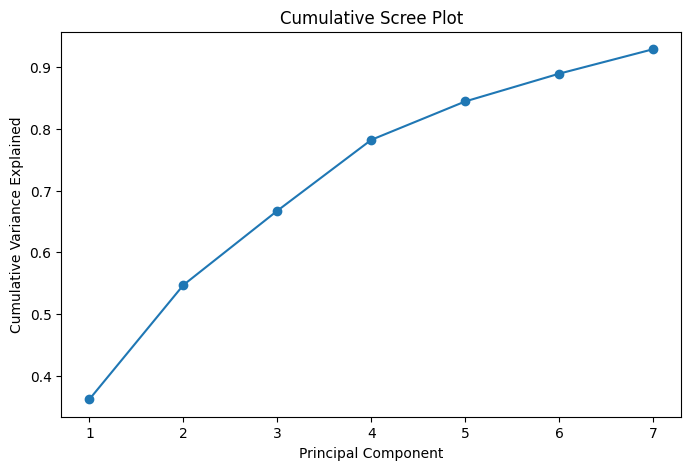

In [7]:
pca = PCA(n_components=7)
pca_scores = pca.fit_transform(X)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(pca.explained_variance_ratio_)+1),
         pca.explained_variance_ratio_.cumsum(),
         marker='o')

plt.xticks(range(1, len(pca.explained_variance_ratio_)+1))
plt.xlabel("Principal Component")
plt.ylabel("Cumulative Variance Explained")
plt.title("Cumulative Scree Plot")
plt.show()

PC1–PC2 cumulative variance ≈ 0.56

PC1–PC3 cumulative variance ≈ 0.68

PC1–PC4 ≈ 0.80

PC1–PC5 ≈ 0.86

PC1–PC6 ≈ 0.90

PC1–PC7 ≈ 0.94

Probably best to use 4 components

## Running PCA for 4 components

In [8]:
# Keeping first two principle components
pca = PCA(n_components=4)
pca_scores = pca.fit_transform(X)

In [9]:
pc_cols = ["PC1", "PC2", "PC3", "PC4"]
outages_tract_pca_scores = pd.DataFrame(pca_scores, columns=pc_cols)

# Add TRACT IDs back
outages_tract_pca_scores["TRACT"] = tract_ids.values

# Create PCA loadings dataframe
outages_tract_loadings = pd.DataFrame(
    pca.components_.T,
    index=features_for_pca,
    columns=pc_cols
)

outages_tract_loadings.to_csv("data_processed/outages_pca_results/outages_tract_loadings.csv", index=True)


In [10]:
fig = px.scatter_3d(
    outages_tract_pca_scores,
    x="PC1",
    y="PC2",
    z="PC3",
    color="PC4",
    hover_name="TRACT",
    opacity=0.7,
    title="3D PCA with PC4 as color"
)

fig.show()

PCA transforms correlated socioeconomic variables into a smaller number of independent components PC1, PC2, PC3, PC4

tract_outages_pca: Displays tract-level PCA scores

PCA Scores: where does each tract lie along these abstract outages axes

Loadings: which variables define each principal component (ie which pattern does PC1, PC2, PC3, and PC4 represent). The are weights linking original variables to each principal component.

## Loadings Interpretation:

### PC1

PC1 measures the overall scale of outages in a tract (more outages, longer outages, more customers affected, more household-minutes lost)

Higher PC1 are tracts with higher outage burden

### PC2

Contrasts how many people outages affect vs how long outages last

Higher: outages affect many customers but are shorter
Lower: outages affect fewer customers but are longer in duration

### PC3

seasonality of outages

high: winter dominant
Low: summer dominant

### PC4

rare severe vs frequent mild outage profiles

high: fewer total outages, but longer on average, affect more customers per outage

lower: more frequent, but shorter and lower impact

# STEP B — Cluster census tracts using PCA scores

Use k-means or hierarchical clustering.

We want to:

    • Cluster tracts based on PC1, PC2, PC3, PC4 scores
    • THEN examine socioeconomic metrics within each cluster

Output per cluster:

    • Socioeconomic profile (low-income, old housing, rural, etc.)
    • Average outage frequency
    • Average outage duration
    • Weather exposure metrics
    
This gives us: which outage types disproportionately affect which communities?

## Choose k (number of clusters)
Via:
- elbow method
- silhouette score

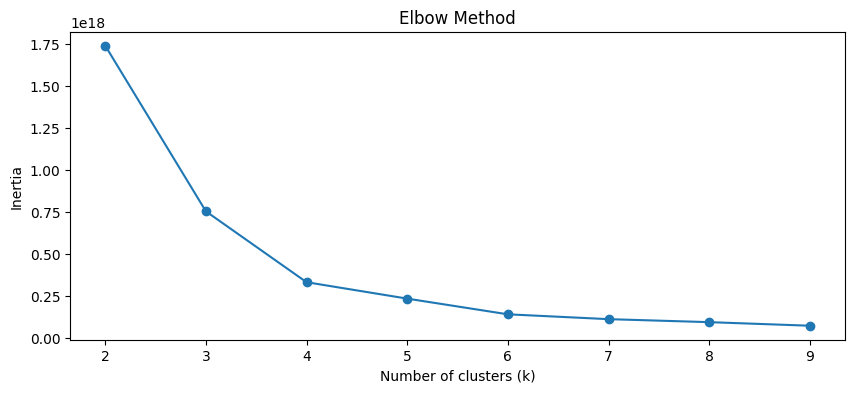

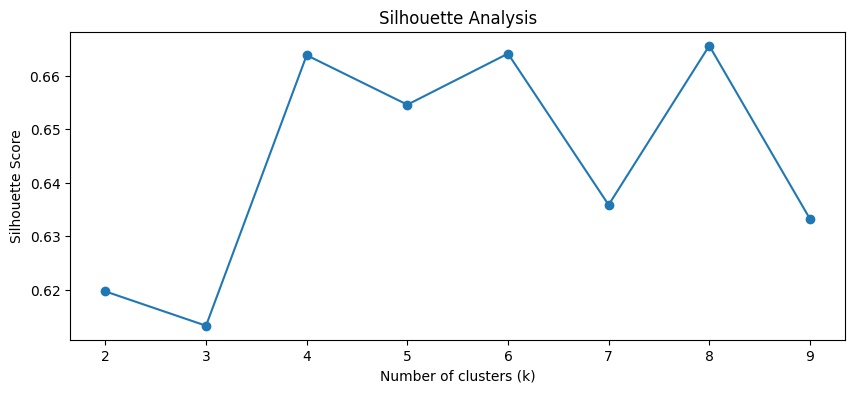

In [11]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

Ks = range(2, 10)
inertias = []
silhouettes = []

for k in Ks:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(outages_tract_pca_scores)
    
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(outages_tract_pca_scores, labels))

# Plot elbow
plt.figure(figsize=(10,4))
plt.plot(Ks, inertias, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

# Plot silhouette
plt.figure(figsize=(10,4))
plt.plot(Ks, silhouettes, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.show()

Choosing k = 3

- Where elbow is most visible before diminishing returns begin
- Has a higher silhouette score than k = 4, 5, 6
    - For silhouette score, it's highest at k = 2, but 2 clusters might oversimpliofy the data

## Run clustering (k-means / hierarchical)

In [12]:
best_k = 4

kmeans = KMeans(n_clusters=best_k, random_state=42)
outages_tract_pca_scores['cluster'] = kmeans.fit_predict(outages_tract_pca_scores)

## Characterize each cluster

Using the unscaled, real socioeconomic variables.

In [13]:
df = tract_outages.merge(outages_tract_pca_scores[['TRACT','cluster']], on='TRACT')

outages_cluster_profiles = df.groupby('cluster')[features_for_pca].mean()
outages_cluster_profiles.to_csv("data_processed/outages_pca_results/outages_cluster_profiles.csv", index=True)


Cluster 0: Moderate outages, moderate impact
- medium total outages
- medium duration
- medium total duration hours
- moderate impact on customers

Middle buden cluster. Outages occur at moderate frequency, last moderate amt of time, and affect a moderate number of customers. Nothing is extreme here.

Cluster 1: Moderately high outages with highg total customer impact
- higher outages than cluster 0
- duration somewhat high
- Total household-minutes out second highest
- total customers affected are high

This cluster experiences somewhat more outages than Cluster 0, but the outages are shorter and affect fewer customers per event. However, because outages are more frequent, the total customer burden remains fairly high.

Cluster 2: high duration, high impact, low frequency
-  highest total outages
- highest mean duration
- highest max duration
- highest total duration hours
- highest total household-minutes out
- lowest summer fraction

Cluster 2 represents tracts with frequent, very long, and high-impact outages. The extreme max durations and very large total outage hours indicate systemic reliability issues.

Cluster 3: moderate frequency but higher impact outages

Cluster 3 has moderate outage frequency, but each outage affects more customers, including the largest max-event sizes. Although durations aren’t extreme, customer impact is high.

## Identify standout tracts directly using PCA scores and distances

### Identify Outliers Using PCA Distance

In [14]:
pc_df = outages_tract_pca_scores[['PC1','PC2','PC3','PC4']].copy()
pc_df['TRACT'] = outages_tract_pca_scores['TRACT']

pc_df['distance'] = np.sqrt(pc_df['PC1']**2 + pc_df['PC2']**2 + pc_df['PC3']**2 + pc_df['PC4']**2)

#Identifying 20 "outliers"
pc_df.nlargest(20, 'distance')


,PC1,PC2,PC3,PC4,TRACT,distance
940,9.501239,-23.498440,-12.061593,26.127026,37087980100,38.347800
149,21.299652,1.566919,0.158758,-5.064216,37021003204,21.949986
150,17.435110,-7.327752,0.085947,-5.361310,37021003205,19.657824
138,17.850478,1.405234,0.452968,-3.331398,37021003002,18.218607
1450,16.261762,-4.095858,0.822062,-3.271116,37121950300,17.105465
1451,15.229747,-2.031584,1.235534,-2.887378,37121950400,15.682347
941,14.145189,-2.718775,0.359161,-4.524356,37089930100,15.102215
139,13.777413,-3.124496,-0.266111,-3.714571,37021003003,14.609875
446,0.660705,6.796671,-4.384096,12.069275,37057061501,14.543692
1150,4.288715,-9.820847,-4.296590,8.652179,37115010500,14.427855


### Use hierarchical clustering (Ward’s method)

Hierarchical clustering can reveal:
2 clusters at the top, then splits into smaller subgroups, no assumption of spherical boundaries

And the dendrogram helps tell a story.

Ward's method merges tracts into clusters by minimizing within-group variance. The height of each merge reflects how different two groups are.

In [15]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

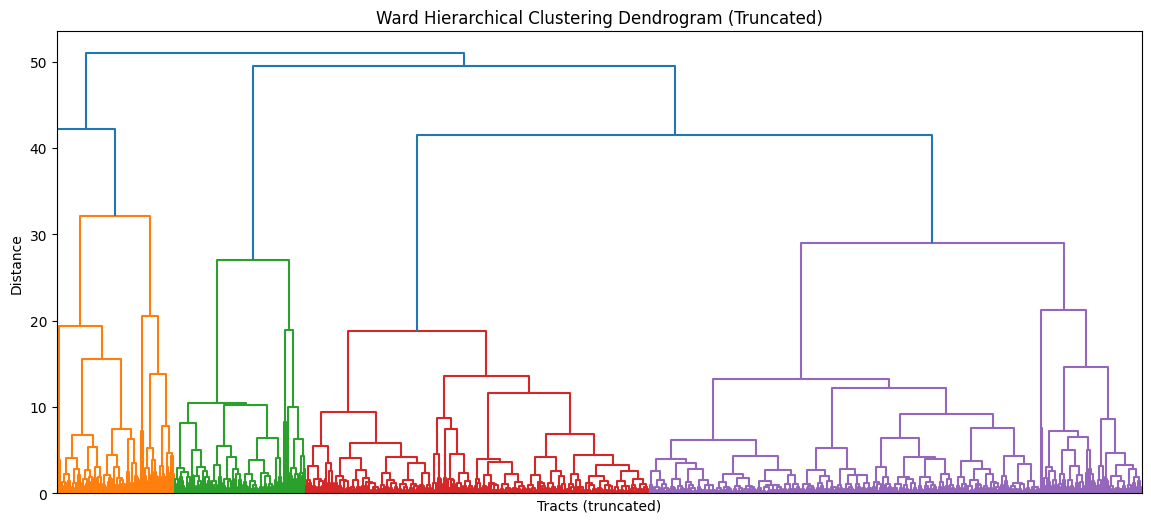

In [16]:
# Use the PCA scores for clustering
X = outages_tract_pca_scores[['PC1', 'PC2', 'PC3','PC4']].reset_index(drop=True)

# Standardize (good practice for hierarchical clustering)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

tract_ids = outages_tract_pca_scores['TRACT'].astype(str).reset_index(drop=True)

# Compute hierarchical clustering using Ward's method
Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(
    Z,
    truncate_mode='level',  # show only top hierarchical structure
    p=30,                   # number of leaf nodes to show
    no_labels=True,
)
plt.title("Ward Hierarchical Clustering Dendrogram (Truncated)")
plt.xlabel("Tracts (truncated)")
plt.ylabel("Distance")
plt.show()

There are three very large jumps:

One around distance ~40

One around distance ~38

One around distance ~33

These represent major cluster separations.

Below those big jumps, groups split into smaller branches.

Ward’s method is suggesting ~3 large natural clusters

### Map PCs or SES variables directly

Map PC1–PC4

In [19]:
tract_geo = gpd.read_file("data_raw/tl_2022_37_tract")
tract_geo['TRACT'] = tract_geo['GEOID'].str[:11]  
tract_geo = tract_geo.to_crs(epsg=4326)

# Merge GeoDataFrame with PCA+cluster data
gdf = tract_geo.merge(
    outages_tract_pca_scores[['TRACT','PC1','PC2','PC3','PC4','cluster']],
    on='TRACT',
    how='left'
)

# Drop tracts missing PCA values (if any)
gdf = gdf.dropna(subset=['PC1','PC2','PC3','PC4','cluster'])

# Ensure GeoDataFrame is in WGS84 (plotly expects EPSG:4326)
gdf = gdf.to_crs(epsg=4326)

# Save an output GeoJSON for other apps / backup
gdf.to_file("data_processed/outages_pca_results/outages_tracts_with_pca_and_clusters.geojson", driver="GeoJSON")
print("Saved tracts_with_pca_and_clusters.geojson")

Saved tracts_with_pca_and_clusters.geojson


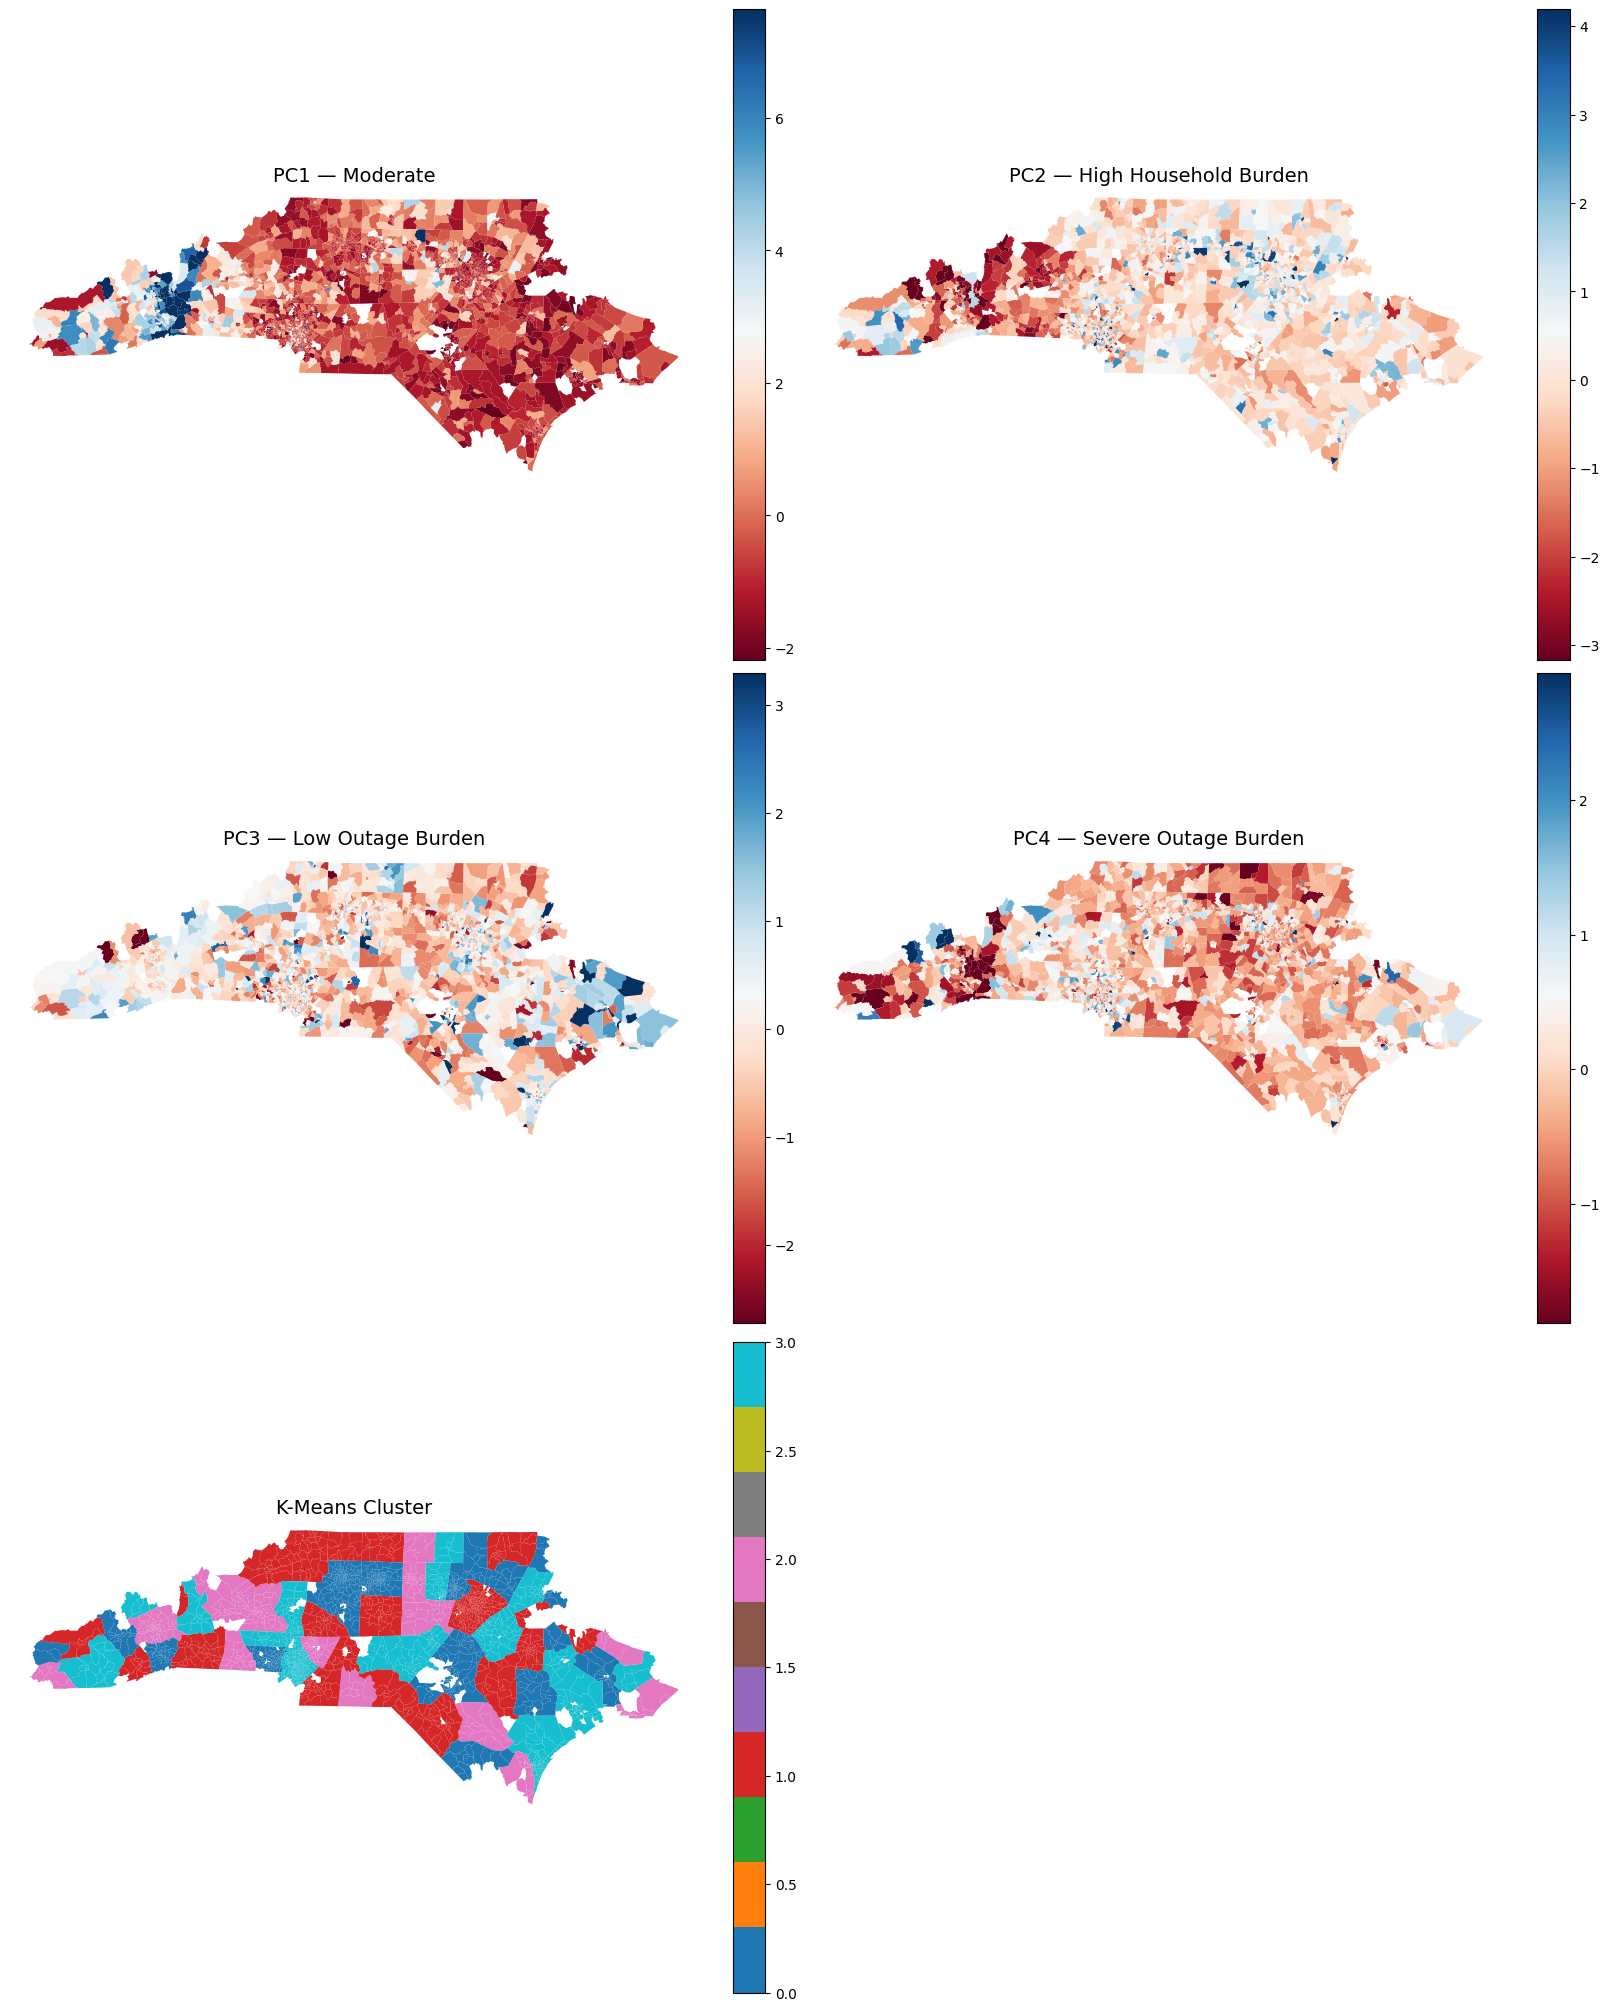

In [20]:
gdf['cluster'] = gdf['cluster'].astype(int)

variables = ['PC1','PC2','PC3','PC4','cluster']
titles = [
    'PC1 — Moderate', 
    'PC2 — High Household Burden', 
    'PC3 — Low Outage Burden', 
    'PC4 — Severe Outage Burden',
    'K-Means Cluster'
]

# compute global bounds and add pad so all subplots show the same full area
xmin, ymin, xmax, ymax = gdf.total_bounds
# fallback if bounds are degenerate / not finite
if not np.all(np.isfinite([xmin, ymin, xmax, ymax])):
    xmin, ymin, xmax, ymax = -1, -1, 1, 1

width = max(xmax - xmin, 1e-6)
height = max(ymax - ymin, 1e-6)
pad_x = max(width * 0.03, 0.001 * width)
pad_y = max(height * 0.03, 0.001 * height)
global_xlim = (xmin - pad_x, xmax + pad_x)
global_ylim = (ymin - pad_y, ymax + pad_y)

fig, axes = plt.subplots(3, 2, figsize=(16, 20), constrained_layout=True)
axes = axes.ravel()

for i, var in enumerate(variables):
    ax = axes[i]

    # skip if no geometries
    if gdf.geometry.is_empty.all() or gdf.geometry.isnull().all():
        ax.text(0.5, 0.5, "No geometries to plot", ha='center', va='center', transform=ax.transAxes)
        ax.set_axis_off()
        continue

    if var == 'cluster':
        gdf.plot(
            column='cluster',
            ax=ax,
            cmap='tab10',
            legend=True,
            linewidth=0,
            edgecolor='none',
            missing_kwds={"color": "lightgrey"}
        )

    else:
        # robust vmin/vmax
        col = gdf[var].replace([np.inf, -np.inf], np.nan).dropna()
        if col.empty:
            # fall back to greys if column missing
            gdf.plot(ax=ax, color='#EEEEEE', edgecolor='#BBBBBB', linewidth=0.25)
            ax.text(0.5, 0.5, f"No valid values for {var}", ha='center', va='center', transform=ax.transAxes)
        else:
            vmin = col.quantile(0.01)
            vmax = col.quantile(0.99)
            if not np.isfinite(vmin) or not np.isfinite(vmax):
                vmin, vmax = col.min(), col.max()
            if np.isclose(vmin, vmax):
                pad = abs(vmin) * 0.01 if vmin != 0 else 1e-6
                vmin -= pad
                vmax += pad

            gdf.plot(
                column=var,
                ax=ax,
                cmap='RdBu',
                legend=True,
                vmin=vmin,
                vmax=vmax,
                linewidth=0,
                edgecolor='none',
                missing_kwds={"color": "lightgrey"}
            )

    # force same geographic extent so the full map displays in every subplot
    ax.set_xlim(global_xlim)
    ax.set_ylim(global_ylim)

    ax.set_title(titles[i], fontsize=14)
    ax.set_axis_off()

# hide the unused 6th plot (if present)
if len(axes) > len(variables):
    axes[len(variables)].set_visible(False)

plt.show()

Saved: data_processed/outages_pca_results/outages_tracts_with_pca_and_clusters.geojson


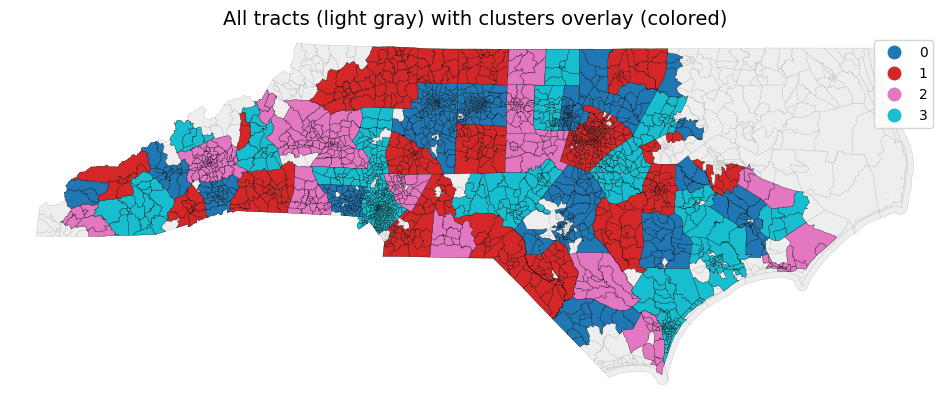

In [29]:
tract_geo['TRACT'] = tract_geo['GEOID'].astype(str)

# ensure geometries in WGS84 lat/lon if needed
tract_geo = tract_geo.to_crs(epsg=4326)

# 2) left-merge PCA/cluster results onto the full set of tracts
# outages_tract_pca_scores must have a 'TRACT' column that matches the GEOID
gdf = tract_geo.merge(
    outages_tract_pca_scores[['TRACT','PC1','PC2','PC3','PC4','cluster']],
    on='TRACT',
    how='left'
)

# 3) don't drop missing PCA rows — instead create helper columns
# Flag which tracts have outage/PCA/cluster data
gdf['has_data'] = ~gdf['PC1'].isna()  # True when PCA data present

# If you want cluster as integer but need placeholder for missing, set to -1
# (useful for categorical plotting)
gdf['cluster_plot'] = gdf['cluster'].fillna(-1).astype(int)

# Optionally convert to a category and set labels (so legend shows 'No data')
gdf['cluster_cat'] = gdf['cluster_plot'].astype('category')
gdf['cluster_cat'] = gdf['cluster_cat'].cat.rename_categories(
    { -1: 'No data', **{int(c): f"Cluster {int(c)}" for c in gdf['cluster_plot'].dropna().unique() if int(c) >= 0}}
)

# 4) Save GeoJSON (GeoJSON supports nulls, but we filled cluster_plot to avoid issues)
out_path = "data_processed/outages_pca_results/outages_tracts_with_pca_and_clusters.geojson"
gdf.to_file(out_path, driver="GeoJSON")
print("Saved:", out_path)

# 5) Plot: base layer (all tracts faint) + overlay of tracts that have data
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Draw full basemap in faint gray so every tract is visible
gdf.plot(ax=ax, color="#EEEEEE", edgecolor="#BBBBBB", linewidth=0.25)

# Overlay tracts that have PCA/cluster data with colors (so missing ones remain pale)
# Example: plot cluster categories
gdf_with = gdf.loc[gdf['has_data']]
if not gdf_with.empty:
    gdf_with.plot(
        column='cluster_plot',
        ax=ax,
        cmap='tab10',
        linewidth=0.2,
        edgecolor='k',
        legend=True,
        categorical=True,
        missing_kwds={"color": "lightgrey"}
    )

# Ensure full extent shows
xmin, ymin, xmax, ymax = gdf.total_bounds
pad_x = (xmax - xmin) * 0.03 if (xmax > xmin) else 0.01
pad_y = (ymax - ymin) * 0.03 if (ymax > ymin) else 0.01
ax.set_xlim(xmin - pad_x, xmax + pad_x)
ax.set_ylim(ymin - pad_y, ymax + pad_y)

ax.set_axis_off()
ax.set_title("All tracts (light gray) with clusters overlay (colored)", fontsize=14)
plt.show()

In [36]:
tract_geo.columns

Index(['STATEFP', 'COUNTYFP', 'TRACTCE', 'GEOID', 'NAME', 'NAMELSAD', 'MTFCC',
       'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON', 'geometry'],
      dtype='object')

tract_geo rows: 2672
unique TRACT in tract_geo: 2672
pca rows: 2264
unique TRACT in PCA: 2264
duplicate PCA rows (first 10):
Empty DataFrame
Columns: [PC1, PC2, PC3, PC4, TRACT, cluster]
Index: []
After merge - total rows: 2672
_merge
both          2264
left_only      408
right_only       0
Name: count, dtype: int64
tracts with no PCA data: 408
Sample missing TRACTs: ['37031970805', '37031970903', '37019020504', '37019020308', '37031970701', '37167931203', '37071031705', '37031970200', '37179021017', '37179021016']
PCA tracts not found in tract_geo (count): 0


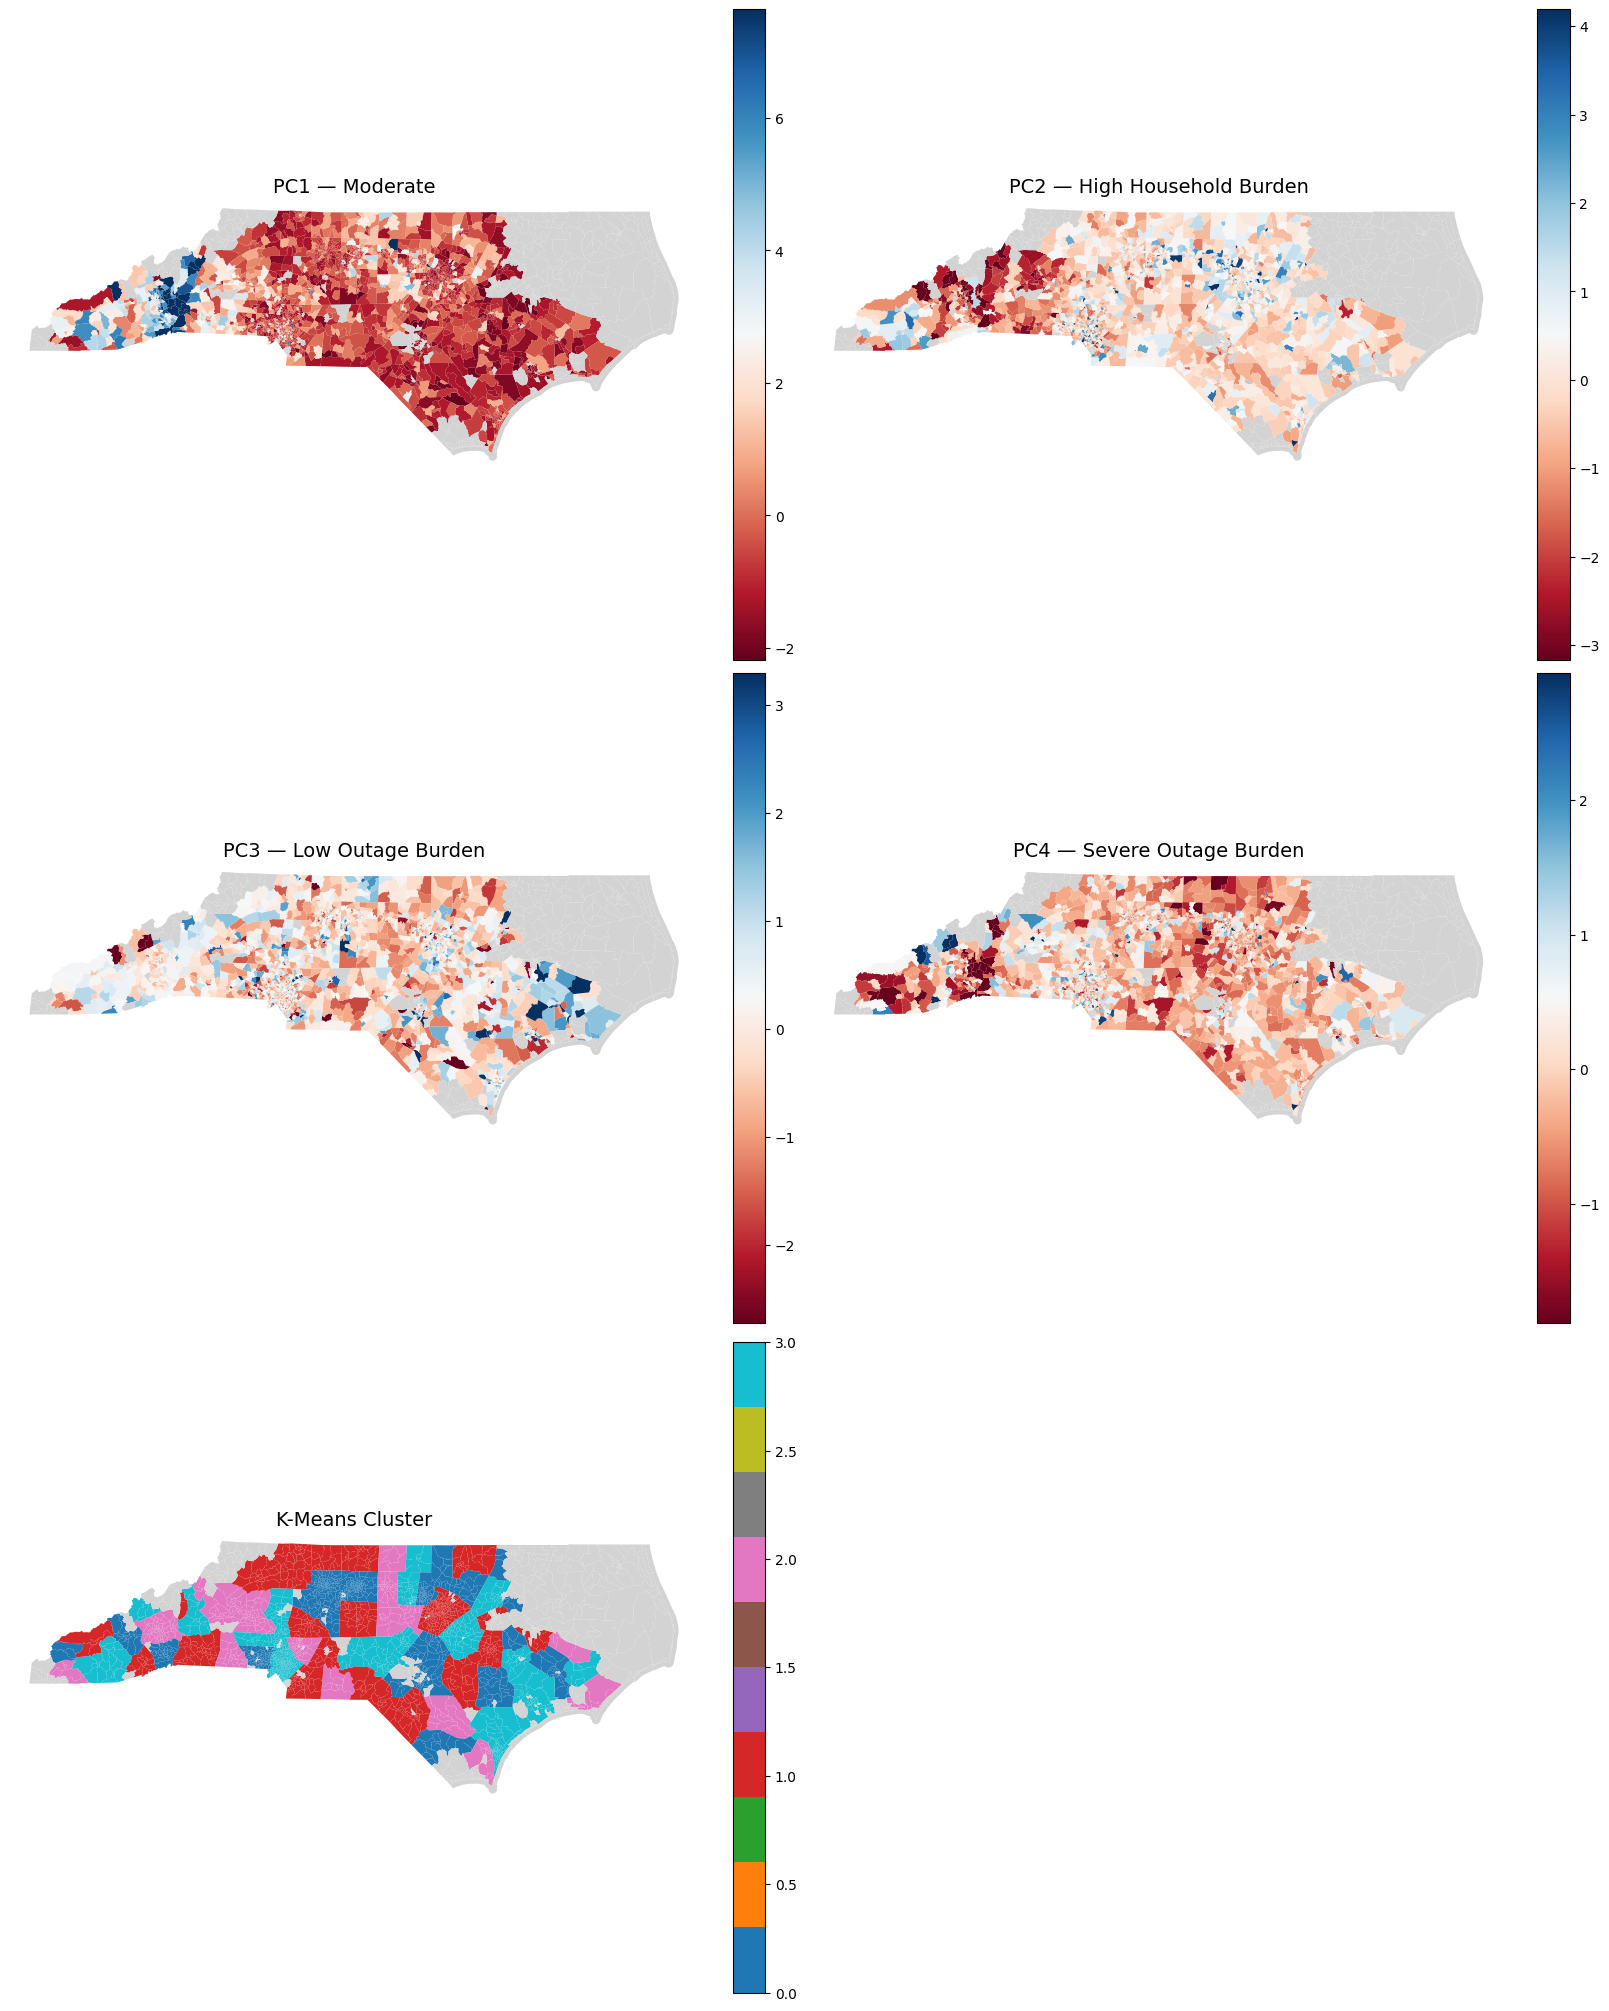

In [38]:
# --- read files (adjust paths if needed) ---
tract_geo = gpd.read_file("data_raw/tl_2022_37_tract")
# ensure GEOID is string and TRACT is 11 chars (state+county+tract usually 11)
tract_geo['GEOID'] = tract_geo['GEOID'].astype(str)
tract_geo['TRACT'] = tract_geo['GEOID'].str[:11].str.zfill(11)

# quick diagnostics about tract_geo
print("tract_geo rows:", len(tract_geo))
print("unique TRACT in tract_geo:", tract_geo['TRACT'].nunique())

# inspect outages_tract_pca_scores
print("pca rows:", len(outages_tract_pca_scores))
# ensure TRACT column is string with 11 chars
outages_tract_pca_scores['TRACT'] = outages_tract_pca_scores['TRACT'].astype(str).str.zfill(11)
print("unique TRACT in PCA:", outages_tract_pca_scores['TRACT'].nunique())

# find duplicates in PCA scores (commonly causes > expected row counts)
dup_pca = outages_tract_pca_scores[outages_tract_pca_scores.duplicated(subset=['TRACT'], keep=False)]
print("duplicate PCA rows (first 10):")
print(dup_pca.head(10))

# Merge GeoDataFrame with PCA+cluster data (use indicator to see merge result)
gdf = tract_geo.merge(
    outages_tract_pca_scores[['TRACT','PC1','PC2','PC3','PC4','cluster']],
    on='TRACT',
    how='left',
    indicator=True
)

print("After merge - total rows:", len(gdf))
print(gdf['_merge'].value_counts())  # shows how many matched vs left_only etc

# which tracts are missing PCA / cluster
missing_mask = gdf['PC1'].isna() & gdf['PC2'].isna() & gdf['PC3'].isna() & gdf['PC4'].isna() & gdf['cluster'].isna()
print("tracts with no PCA data:", missing_mask.sum())
if missing_mask.sum() > 0:
    print("Sample missing TRACTs:", gdf.loc[missing_mask, 'TRACT'].head(10).tolist())

# If PCA file had extra tracts not in tract_geo, show them:
pca_tracts_not_in_geo = set(outages_tract_pca_scores['TRACT']) - set(tract_geo['TRACT'])
print("PCA tracts not found in tract_geo (count):", len(pca_tracts_not_in_geo))
if pca_tracts_not_in_geo:
    print("Example:", list(pca_tracts_not_in_geo)[:10])

# Do NOT drop missing PCA rows if you want them plotted as gray. Only drop if you must save trimmed geojson.
# Ensure GeoDataFrame is in WGS84 (plotting / plotly expectation)
gdf = gdf.to_crs(epsg=4326)

# If cluster exists, make it int-ish but preserve NaNs (use pandas Int64 for nullable ints)
if 'cluster' in gdf.columns:
    try:
        gdf['cluster'] = gdf['cluster'].astype('Int64')  # nullable integer
    except Exception:
        # fallback: keep as object / float
        pass

# ---------- plotting (geopandas + matplotlib) ----------
variables = ['PC1','PC2','PC3','PC4','cluster']
titles = [
    'PC1 — Moderate',
    'PC2 — High Household Burden',
    'PC3 — Low Outage Burden',
    'PC4 — Severe Outage Burden',
    'K-Means Cluster'
]

# compute global bounds from the full tract layer so every subplot uses same extent
xmin, ymin, xmax, ymax = tract_geo.total_bounds
if not np.all(np.isfinite([xmin, ymin, xmax, ymax])):
    xmin, ymin, xmax, ymax = -1, -1, 1, 1

width = max(xmax - xmin, 1e-6)
height = max(ymax - ymin, 1e-6)
pad_x = max(width * 0.03, 0.001 * width)
pad_y = max(height * 0.03, 0.001 * height)
global_xlim = (xmin - pad_x, xmax + pad_x)
global_ylim = (ymin - pad_y, ymax + pad_y)

fig, axes = plt.subplots(3, 2, figsize=(16, 20), constrained_layout=True)
axes = axes.ravel()

for i, var in enumerate(variables):
    ax = axes[i]

    # skip if no geometries at all (unlikely after reading shapefile)
    if gdf.geometry.is_empty.all() or gdf.geometry.isnull().all():
        ax.text(0.5, 0.5, "No geometries to plot", ha='center', va='center', transform=ax.transAxes)
        ax.set_axis_off()
        continue

    if var == 'cluster':
        # for cluster (categorical) use a categorical colormap; missing will be lightgrey
        gdf.plot(
            column='cluster',
            ax=ax,
            cmap='tab10',
            legend=True,
            linewidth=0,
            edgecolor='none',
            missing_kwds={"color": "lightgrey", "edgecolor": "none"}
        )
    else:
        # robust vmin/vmax on numeric PC columns
        col = gdf[var].replace([np.inf, -np.inf], np.nan).dropna()
        if col.empty:
            gdf.plot(ax=ax, color='#EEEEEE', edgecolor='#BBBBBB', linewidth=0.25)
            ax.text(0.5, 0.5, f"No valid values for {var}", ha='center', va='center', transform=ax.transAxes)
        else:
            vmin = col.quantile(0.01)
            vmax = col.quantile(0.99)
            if not np.isfinite(vmin) or not np.isfinite(vmax):
                vmin, vmax = col.min(), col.max()
            if np.isclose(vmin, vmax):
                pad = abs(vmin) * 0.01 if vmin != 0 else 1e-6
                vmin -= pad
                vmax += pad

            gdf.plot(
                column=var,
                ax=ax,
                cmap='RdBu',
                legend=True,
                vmin=vmin,
                vmax=vmax,
                linewidth=0,
                edgecolor='none',
                missing_kwds={"color": "lightgrey", "edgecolor": "none"}
            )

    ax.set_xlim(global_xlim)
    ax.set_ylim(global_ylim)
    ax.set_title(titles[i], fontsize=14)
    ax.set_axis_off()

# hide the unused 6th plot (if present)
if len(axes) > len(variables):
    axes[len(variables)].set_visible(False)

plt.show()

In [39]:
# ensure both TRACT columns are comparable (strings, zero-padded 11 chars)
tract_geo['TRACT'] = tract_geo['TRACT'].astype(str).str.zfill(11)
outages_tract_pca_scores['TRACT'] = outages_tract_pca_scores['TRACT'].astype(str).str.zfill(11)

# set difference
pca_tract_set = set(outages_tract_pca_scores['TRACT'].unique())
geo_tract_set = set(tract_geo['TRACT'].unique())

tracts_only_in_geo = sorted(list(geo_tract_set - pca_tract_set))

print("Count of tracts in tract_geo but NOT in PCA file:", len(tracts_only_in_geo))
print("First 20 examples:", tracts_only_in_geo[:20])

Count of tracts in tract_geo but NOT in PCA file: 408
First 20 examples: ['37005950100', '37005950200', '37005950300', '37009970200', '37009970300', '37009970400', '37009970501', '37009970502', '37009970701', '37009970702', '37009970801', '37009970802', '37011930100', '37011930200', '37013930101', '37013930102', '37013930200', '37013930400', '37013930501', '37013930502']


## This creates the interactive plots that take up more space

In [ ]:
# ensure geojson exists
geojson = json.loads(gdf.to_json())

# make sure gid exists and matches geojson feature properties
gdf['gid'] = gdf['TRACT'].astype(str)

center = {"lat": 35.5, "lon": -79.0}

def make_plotly_choropleth(var, title, categorical=False):
    if not categorical:
        fig = px.choropleth_mapbox(
            gdf,
            geojson=geojson,
            locations='gid',
            color=var,
            featureidkey='properties.gid',   # matches property name in geojson
            mapbox_style='carto-positron',
            center=center,
            zoom=6,
            opacity=0.7,
            hover_data=['gid','TRACT','PC1','PC2','PC3','hc_cluster'],
            title=title
        )
    else:
        fig = px.choropleth_mapbox(
            gdf,
            geojson=geojson,
            locations='gid',
            color=var,
            featureidkey='properties.gid',
            mapbox_style='carto-positron',
            center=center,
            zoom=6,
            opacity=0.8,
            hover_data=['gid','TRACT','PC1','PC2','PC3','hc_cluster'],
            title=title
        )
    fig.update_layout(margin={"r":0,"t":35,"l":0,"b":0})
    return fig

fig_pc1 = make_plotly_choropleth('PC1', 'PC1 — Structural Disadvantage', categorical=False)
fig_pc2 = make_plotly_choropleth('PC2', 'PC2 — Aging / Mobility', categorical=False)
fig_pc3 = make_plotly_choropleth('PC3', 'PC3 — Older Suburban Stability', categorical=False)
fig_clusters = make_plotly_choropleth('hc_cluster', 'Ward clusters (interactive)', categorical=True)

# show in notebook
fig_pc1.show()
fig_pc2.show()
fig_pc3.show()
fig_clusters.show()

# save HTMLs
fig_pc1.write_html("pc1_map_interactive.html")
fig_pc2.write_html("pc2_map_interactive.html")
fig_pc3.write_html("pc3_map_interactive.html")
fig_clusters.write_html("clusters_map_interactive.html")
print("Saved interactive HTML maps.")

## Merge with socioeconomic + weather summaries (tract)

I have:
- tract_socioeconomic_unscaled
- tract_weather

Which are summaries of socioeconomics and weather for each tract.

This will help compute:
- Socioeconomic metrics per cluster
- Weather exposure per cluster

In [22]:
tract_socioeconomic = pd.read_csv('data_processed/PCA_data/tract_socioeconomic_unscaled.csv')
tract_weather = pd.read_csv('data_processed/PCA_data/tract_weather.csv')

# Ensure TRACT columns are strings and zero-padded
outages_tract_pca_scores['TRACT'] = outages_tract_pca_scores['TRACT'].astype(str)
tract_socioeconomic['TRACT'] = tract_socioeconomic['TRACT'].astype(str)
tract_weather['TRACT'] = tract_weather['TRACT'].astype(str)
tract_outages['TRACT'] = tract_outages['TRACT'].astype(str)

#MERGE DATSETS
# Merge PCA/cluster -> outages -> weather (left join on PCA tracts)
df = outages_tract_pca_scores[['TRACT','PC1','PC2','PC3','PC4','cluster']].merge(
    tract_socioeconomic, on='TRACT', how='left'
).merge(
    tract_weather, on='TRACT', how='left'
).merge(
    tract_outages, on = 'TRACT', how = 'left'
)


In [29]:
#DEFINING METRICS TO SUMMARIZE (from tract_socioeconomic and tract_weather)
socioeconomic_metrics = [
    'median_household_income',
    'pct_below_50pct_poverty',
    'pct_no_vehicle',
    'pct_renters_cost_burdened',
    'pct_over65',
    'pct_with_disability',
    'pct_nonwhite'
]

weather_metrics = [
    'max_gust_during_outage_days',
    'mean_wind_on_outage_days',
    'total_precip_on_outage_days',
    'mean_soilmoist_on_outage_days'
]

outage_metrics = [
    'total_outages', 'mean_duration_hours',
    'median_duration_hours', 'max_duration_hours', 'total_duration_hours',
    'mean_customers_affected', 'max_customers_affected',
    'total_customers_affected', 'total_customer_minutes_out',
    'pct_outages_in_summer', 'pct_outages_in_winter'
]

#keeping metrics that exist
metrics = [m for m in (socioeconomic_metrics + weather_metrics + outage_metrics) if m in df.columns]

# Per-cluster summary table (mean, median, std, count)
agg_funcs = {m: ['mean','median','std','count'] for m in metrics}
cluster_summary = df.groupby('cluster').agg(agg_funcs)

# flatten MultiIndex columns
cluster_summary.columns = ['_'.join(col).strip() for col in cluster_summary.columns.values]
cluster_summary = cluster_summary.reset_index().sort_values('cluster')

In [30]:
# Per-cluster rates, outages per 1000 people, customer-minutes per capita
df['outages_per_1000'] = df['total_outages'] / df['total_population'] * 1000
df['customer_minutes_per_capita'] = df['total_customer_minutes_out'] / df['total_population']
per_cluster_rates = df.groupby('cluster')[['outages_per_1000','customer_minutes_per_capita']].agg(['mean','median','std']).reset_index()

# STEP C — Identify outlier clusters

Define outliers as:

    • Tracts where outage frequency/duration is > 2 standard deviations above cluster mean
    • Tracts with high weather exposure but low outages (or vice versa)

In [31]:
# Flag per-tract outliers within each cluster (z-score within cluster)
# Compute z-scores within each cluster for a small set of key metrics:
key_metrics = socioeconomic_metrics + weather_metrics
key_metrics = [m for m in key_metrics if m in df.columns]

# compute z-scores grouped by cluster
def z_within_group(group, cols):
    return group[cols].transform(lambda x: (x - x.mean()) / x.std(ddof=0))

zcols = [f"{m}_z_within_cluster" for m in key_metrics]
df[zcols] = z_within_group(df, key_metrics)

# Flag outliers: absolute z > 2 → unusual
for m, zcol in zip(key_metrics, zcols):
    df[f"{m}_is_outlier"] = df[zcol].abs() > 2

# Create an "outlier score" as sum of flags
outlier_flag_cols = [c for c in df.columns if c.endswith('_is_outlier')]
df['outlier_score'] = df[outlier_flag_cols].sum(axis=1)

# Top standout tracts by outlier_score, tiebreaker by max z magnitude
df['max_abs_z'] = df[zcols].abs().max(axis=1)
outlier_list = df.sort_values(['outlier_score','max_abs_z'], ascending=[False, False]).head(50)

Saved: outlier_tracts_static_map_polygons_only_outages_pca.png


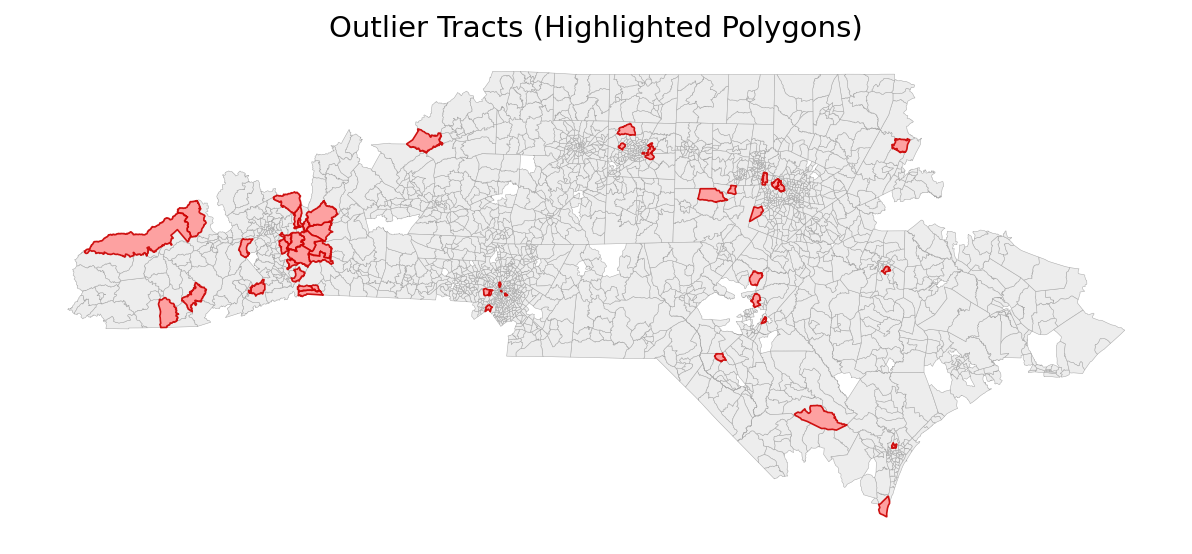

In [32]:
#gdf['TRACT'] = gdf['TRACT'].astype(str).str.zfill(6)
outlier_df = outlier_list.copy()
#outlier_df['TRACT'] = outlier_df['TRACT'].astype(str).str.zfill(6)

# Merge outlier flag into full GeoDataFrame
gdf_map = gdf.merge(
    outlier_df[['TRACT','outlier_score','max_abs_z']],
    on='TRACT',
    how='left'
)

# Outlier polygons only
outlier_gdf = gdf_map[gdf_map['outlier_score'].notna()].copy()

# Plot
fig, ax = plt.subplots(1, 1, figsize=(10, 10), dpi=150)

# Plot all tracts in very light gray
gdf_map.plot(ax=ax, color='#EDEDED', edgecolor='#AAAAAA', linewidth=0.25)

# Highlight outlier polygons (NO centroids, NO dots)
outlier_gdf.plot(ax=ax,
                 facecolor='#ff9999',   # soft red fill
                 edgecolor='#cc0000',   # darker outline
                 linewidth=0.8,
                 alpha=0.9)

# Clean up
ax.set_axis_off()
ax.set_title("Outlier Tracts (Highlighted Polygons)", fontsize=14)

# Save to file
out_path = "outlier_tracts_static_map_polygons_only_outages_pca.png"
plt.savefig(out_path, bbox_inches='tight', pad_inches=0.1)
print(f"Saved: {out_path}")

plt.show()

In [39]:
#SAVE RESULTS
cluster_summary.to_csv("data_processed/outages_pca_results/cluster_outage_weather_summary.csv", index=False)
df.to_csv("data_processed/outages_pca_results/tracts_with_clusters_outage_weather.csv", index=False)
outlier_list.to_csv("data_processed/outages_pca_results/top50_standout_tracts.csv", index=False)
print("Saved cluster_outage_weather_summary.csv, tracts_with_clusters_outage_weather.csv, top50_standout_tracts.csv")

Saved cluster_outage_weather_summary.csv, tracts_with_clusters_outage_weather.csv, top50_standout_tracts.csv


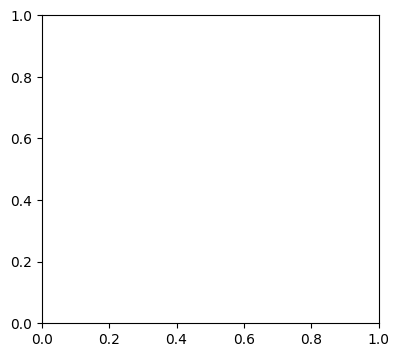

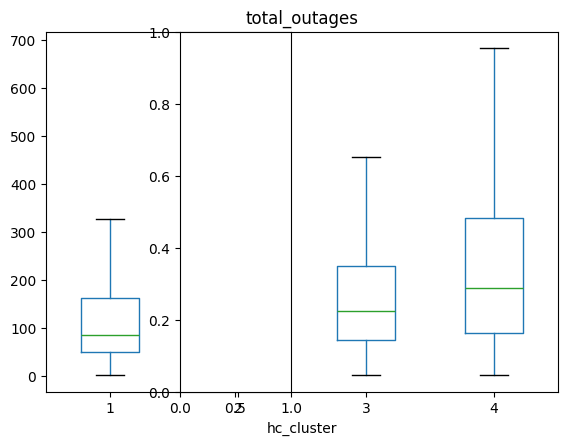

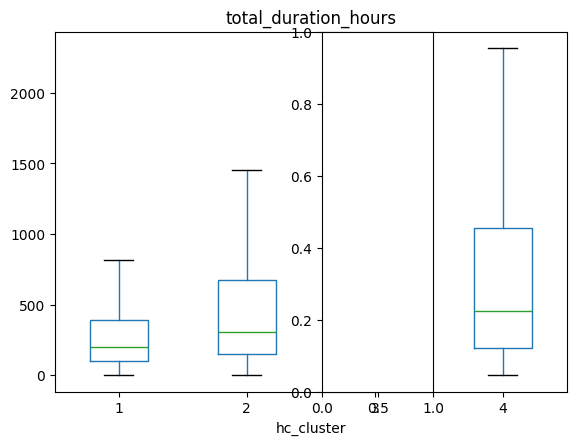

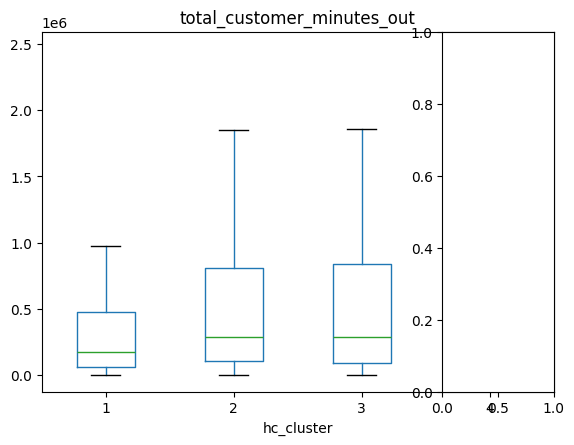

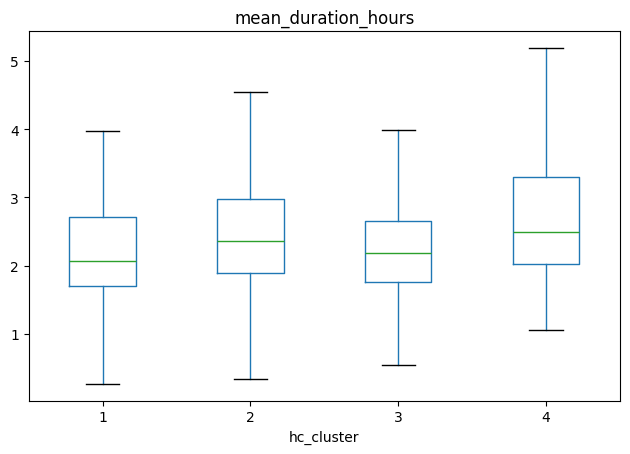

In [25]:
# Quick boxplots for a few key metrics by cluster
plot_metrics = [m for m in ['total_outages','total_duration_hours','total_customer_minutes_out','mean_duration_hours'] if m in df.columns]
n = len(plot_metrics)
plt.figure(figsize=(5*n,4))
for i, m in enumerate(plot_metrics, 1):
    plt.subplot(1, n, i)
    df.boxplot(column=m, by='hc_cluster', grid=False, showfliers=False)
    plt.title(m)
    plt.suptitle('')
plt.tight_layout()
plt.show()

In [88]:
cluster_summary.columns

Index(['cluster', 'median_household_income_mean',
       'median_household_income_median', 'median_household_income_std',
       'median_household_income_count', 'pct_below_50pct_poverty_mean',
       'pct_below_50pct_poverty_median', 'pct_below_50pct_poverty_std',
       'pct_below_50pct_poverty_count', 'pct_no_vehicle_mean',
       'pct_no_vehicle_median', 'pct_no_vehicle_std', 'pct_no_vehicle_count',
       'pct_renters_cost_burdened_mean', 'pct_renters_cost_burdened_median',
       'pct_renters_cost_burdened_std', 'pct_renters_cost_burdened_count',
       'pct_over65_mean', 'pct_over65_median', 'pct_over65_std',
       'pct_over65_count', 'pct_with_disability_mean',
       'pct_with_disability_median', 'pct_with_disability_std',
       'pct_with_disability_count', 'pct_nonwhite_mean', 'pct_nonwhite_median',
       'pct_nonwhite_std', 'pct_nonwhite_count', 'total_population_mean',
       'total_population_median', 'total_population_std',
       'total_population_count', 'max_gust_du

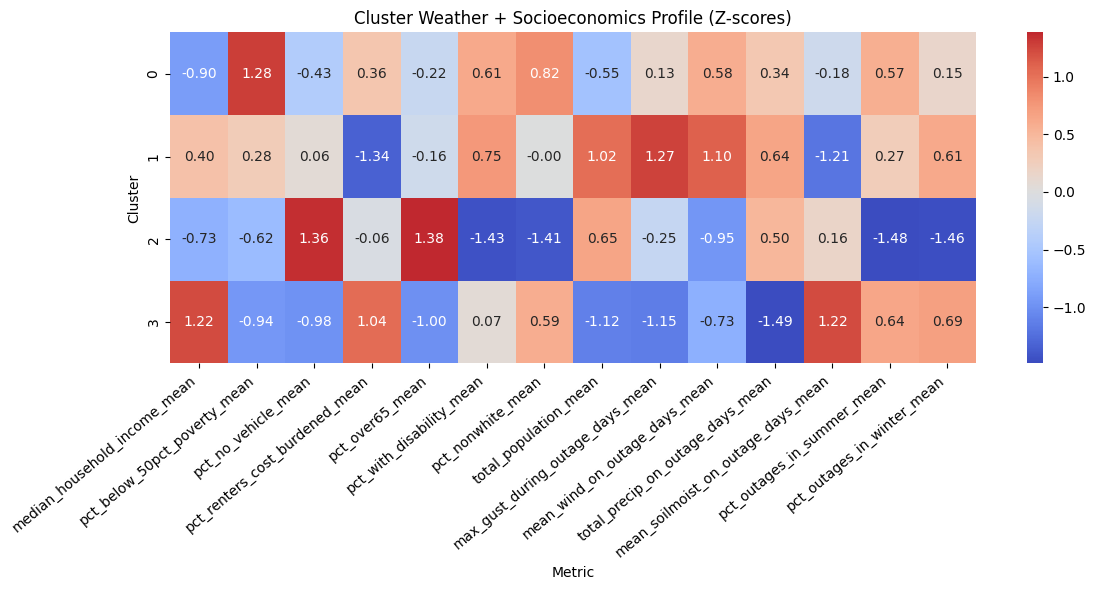

In [28]:
#image creating with the cluster summary

# Columns we want to use (as defined above)
cols = [
    'median_household_income_mean',
    'pct_below_50pct_poverty_mean',
    'pct_no_vehicle_mean',
    'pct_renters_cost_burdened_mean',
    'pct_over65_mean',
    'pct_with_disability_mean',
    'pct_nonwhite_mean',
    'total_population_mean',
    'max_gust_during_outage_days_mean',
    'mean_wind_on_outage_days_mean',
    'total_precip_on_outage_days_mean',
    'mean_soilmoist_on_outage_days_mean',
    'pct_outages_in_summer_mean',
    'pct_outages_in_winter_mean'
    
]
#cluster-level z-scores (above/below average)
cluster_summary_std = cluster_summary.copy()
cluster_summary_std[cols] = cluster_summary_std[cols].apply(
    lambda x: (x - x.mean()) / x.std()
)

import seaborn as sns

heatmap_data = cluster_summary_std.set_index('cluster')[cols]

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Cluster Weather + Socioeconomics Profile (Z-scores)")
plt.xlabel("Metric")
plt.ylabel("Cluster")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.show()